In [1]:
import datetime
import datetime as dt

import numpy as np
from matplotlib import pyplot as plt
from netCDF4 import Dataset
import pandas as pd
from scipy.optimize import minimize
import xarray as xr

from xcube.core.store import new_data_store
from xcube.core.chunk import chunk_dataset

In [2]:
INPUT_DIR = "input_irrigation_2years"

In [3]:
irr_store = new_data_store("file", root=INPUT_DIR)

In [4]:
irr_store.list_data_ids()

['clms.zarr',
 'irrigation_input.zarr',
 'calibrated.zarr',
 'era5.zarr',
 'landcover2020global.zarr']

In [5]:
ds = irr_store.open_data("irrigation_input.zarr")
ds = chunk_dataset(ds, {"time": -1, "lat": 10, "lon": 10})


In [6]:
ds

<xarray.Dataset> Size: 7GB
Dimensions:      (time: 731, lat: 448, lon: 896)
Coordinates:
  * lat          (lat) float64 4kB 40.0 40.01 40.02 40.03 ... 43.98 43.99 44.0
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
    spatial_ref  int64 8B ...
  * time         (time) datetime64[ns] 6kB 2020-01-01 2020-01-02 ... 2021-12-31
Data variables:
    SWI          (time, lat, lon) float64 2GB dask.array<chunksize=(731, 10, 10), meta=np.ndarray>
    lc_binary    (lat, lon) uint8 401kB dask.array<chunksize=(10, 10), meta=np.ndarray>
    pev          (time, lat, lon) float32 1GB dask.array<chunksize=(731, 10, 10), meta=np.ndarray>
    sf           (time, lat, lon) float32 1GB dask.array<chunksize=(731, 10, 10), meta=np.ndarray>
    stl1         (time, lat, lon) float32 1GB dask.array<chunksize=(731, 10, 10), meta=np.ndarray>
    tp           (time, lat, lon) float32 1GB dask.array<chunksize=(731, 10, 10), meta=np.ndarray>
Attributes:
    date_modified:              2025-09-05T11:43:44.565819
    geospatial_bounds:          POLYGON((-4.410714287500187 40.33928571249878...
    geospatial_bounds_crs:      CRS84
    geospatial_lat_max:         43.19642857321242
    geospatial_lat_min:         40.339285712498786
    geospatial_lat_resolution:  0.008928575
    geospatial_lat_units:       degrees_north
    geospatial_lon_max:         2.160714287499627
    geospatial_lon_min:         -4.410714287500187
    geospatial_lon_resolution:  0.008928575
    geospatial_lon_units:       degrees_east

In [7]:
calibration = irr_store.open_data("calibrated.zarr")
calibration = calibration.assign_coords(params=["a", "b", "z", "RF"])
calibration = chunk_dataset(calibration, {"lat": 10, "lon": 10})
calibration

<xarray.Dataset> Size: 13MB
Dimensions:      (lat: 448, lon: 896, params: 4)
Coordinates:
  * lat          (lat) float64 4kB 40.0 40.01 40.02 40.03 ... 43.98 43.99 44.0
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
    spatial_ref  int64 8B ...
  * params       (params) <U2 32B 'a' 'b' 'z' 'RF'
Data variables:
    calibration  (lat, lon, params) float64 13MB dask.array<chunksize=(10, 10, 2), meta=np.ndarray>

In [8]:
def ts_smet4irr(sm, et, a, b, z, RF, thr=None):
    p_sim = z * (sm[1:] - sm[:-1]) \
          + ((a * sm[1:]**b + a * sm[:-1]**b) / 2.) \
          + ((RF * sm[1:] * et[1:] + RF * sm[:-1] * et[:-1]) / 2.)

    p_sim[abs(np.diff(sm)) <= 0.001] = 0.0
    p_sim[p_sim < 1.0] = 0.0
    return np.clip(p_sim, 0, thr)


result = xr.apply_ufunc(
    ts_smet4irr,
    ds["SWI"],
    ds["pev"],
    calibration["calibration"].sel(params="a"),
    calibration["calibration"].sel(params="b"),
    calibration["calibration"].sel(params="z"),
    calibration["calibration"].sel(params="RF"),
    input_core_dims=[["time"], ["time"], [], [], [], []],
    output_core_dims=[["time2"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float],
    output_sizes={"time2": ds.sizes["time"] - 1}
)


/tmp/ipykernel_688913/698073570.py:11: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  result = xr.apply_ufunc(


In [ ]:
from dask.distributed import Client, LocalCluster
import xarray as xr

cluster = LocalCluster(n_workers=4, threads_per_worker=1)
client = Client(cluster)
print(client)

In [10]:
%%time
psim = result.compute()

CPU times: user 42.3 s, sys: 8.88 s, total: 51.2 s
Wall time: 58.3 s


In [11]:
psim

<xarray.DataArray (lat: 448, lon: 896, time2: 730)> Size: 2GB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], shape=(448, 896, 730))
Coordinates:
  * lat          (lat) float64 4kB 40.0 40.01 40.02 40.03 ... 43.98 43.99 44.0
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
    spatial_ref  int64 8B 0
Dimensions without coordinates: time2

In [12]:
client.shutdown()

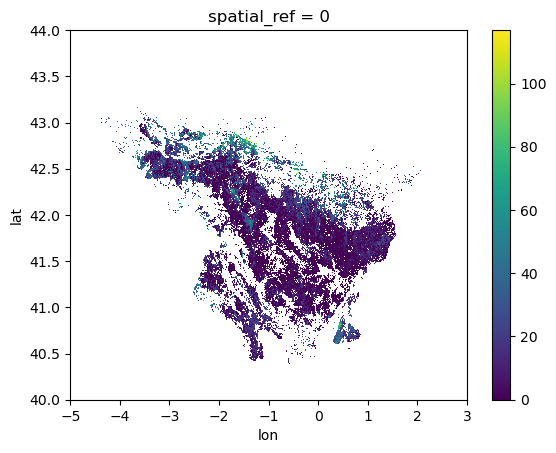

In [13]:
psim.isel(time2=300).plot()

In [14]:
psim = psim.rename({"time2": "time"})
psim

<xarray.DataArray (lat: 448, lon: 896, time: 730)> Size: 2GB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], shape=(448, 896, 730))
Coordinates:
  * lat          (lat) float64 4kB 40.0 40.01 40.02 40.03 ... 43.98 43.99 44.0
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
    spatial_ref  int64 8B 0
Dimensions without coordinates: time

In [15]:
time_coord = ds["time"].values[1:]

In [16]:
psim = psim.assign_coords(time=time_coord)

In [17]:
psim

<xarray.DataArray (lat: 448, lon: 896, time: 730)> Size: 2GB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], shape=(448, 896, 730))
Coordinates:
  * lat          (lat) float64 4kB 40.0 40.01 40.02 40.03 ... 43.98 43.99 44.0
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
    spatial_ref  int64 8B 0
  * time         (time) datetime64[ns] 6kB 2020-01-02 2020-01-03 ... 2021-12-31

In [ ]:
irr_store.write_data(psim.to_dataset(name="sim"), "sim.zarr")

In [19]:
sim = irr_store.open_data("sim.zarr")
sim

<xarray.Dataset> Size: 2GB
Dimensions:      (lat: 448, lon: 896, time: 730)
Coordinates:
  * lat          (lat) float64 4kB 40.0 40.01 40.02 40.03 ... 43.98 43.99 44.0
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
    spatial_ref  int64 8B ...
  * time         (time) datetime64[ns] 6kB 2020-01-02 2020-01-03 ... 2021-12-31
Data variables:
    sim          (lat, lon, time) float64 2GB dask.array<chunksize=(28, 112, 92), meta=np.ndarray>

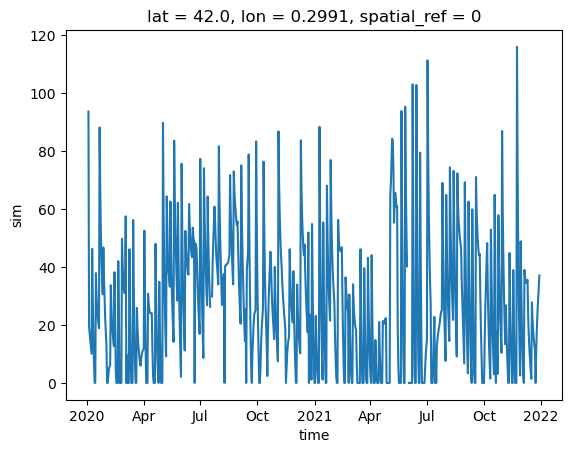

/home/yogesh/Projects/BC/irrigation-processor/.pixi/envs/default/lib/python3.12/site-packages/dask/_task_spec.py:759: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)


In [20]:
sim.sim.sel(lat=42.0, lon=0.3, method="nearest").plot()

In [21]:
IRR = sim - ds['tp'].isel(time=slice(1,None))
IRR_clipped = IRR.clip(0, 1000)
IRR_clipped = IRR_clipped.where(IRR_clipped/ ds['tp'].isel(time=slice(1,None)) >= 0.2, 0)
IRR_clipped

/home/yogesh/Projects/BC/irrigation-processor/.pixi/envs/default/lib/python3.12/site-packages/dask/array/core.py:5003: PerformanceWarning: Increasing number of chunks by factor of 10
  result = blockwise(


<xarray.Dataset> Size: 2GB
Dimensions:      (lat: 448, lon: 896, time: 730)
Coordinates:
  * lat          (lat) float64 4kB 40.0 40.01 40.02 40.03 ... 43.98 43.99 44.0
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
    spatial_ref  int64 8B 0
  * time         (time) datetime64[ns] 6kB 2020-01-02 2020-01-03 ... 2021-12-31
Data variables:
    sim          (lat, lon, time) float64 2GB dask.array<chunksize=(10, 10, 92), meta=np.ndarray>

In [22]:
IRR_clipped = IRR_clipped.transpose("time", "lat", "lon")
IRR_clipped

<xarray.Dataset> Size: 2GB
Dimensions:      (lat: 448, lon: 896, time: 730)
Coordinates:
  * lat          (lat) float64 4kB 40.0 40.01 40.02 40.03 ... 43.98 43.99 44.0
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
    spatial_ref  int64 8B 0
  * time         (time) datetime64[ns] 6kB 2020-01-02 2020-01-03 ... 2021-12-31
Data variables:
    sim          (time, lat, lon) float64 2GB dask.array<chunksize=(92, 10, 10), meta=np.ndarray>

In [23]:
IRR_clipped_monthly = IRR_clipped.resample(time="M").sum(dim="time")

/home/yogesh/Projects/BC/irrigation-processor/.pixi/envs/default/lib/python3.12/site-packages/xarray/groupers.py:509: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


In [24]:
IRR_clipped_monthly

<xarray.Dataset> Size: 77MB
Dimensions:      (time: 24, lat: 448, lon: 896)
Coordinates:
  * lat          (lat) float64 4kB 40.0 40.01 40.02 40.03 ... 43.98 43.99 44.0
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
    spatial_ref  int64 8B 0
  * time         (time) datetime64[ns] 192B 2020-01-31 2020-02-29 ... 2021-12-31
Data variables:
    sim          (time, lat, lon) float64 77MB dask.array<chunksize=(1, 10, 10), meta=np.ndarray>

In [25]:
IRR_monthly_mean = IRR_clipped_monthly.mean(dim=("lat", "lon"))
IRR_monthly_mean

<xarray.Dataset> Size: 392B
Dimensions:      (time: 24)
Coordinates:
    spatial_ref  int64 8B 0
  * time         (time) datetime64[ns] 192B 2020-01-31 2020-02-29 ... 2021-12-31
Data variables:
    sim          (time) float64 192B dask.array<chunksize=(1,), meta=np.ndarray>

/home/yogesh/Projects/BC/irrigation-processor/.pixi/envs/default/lib/python3.12/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


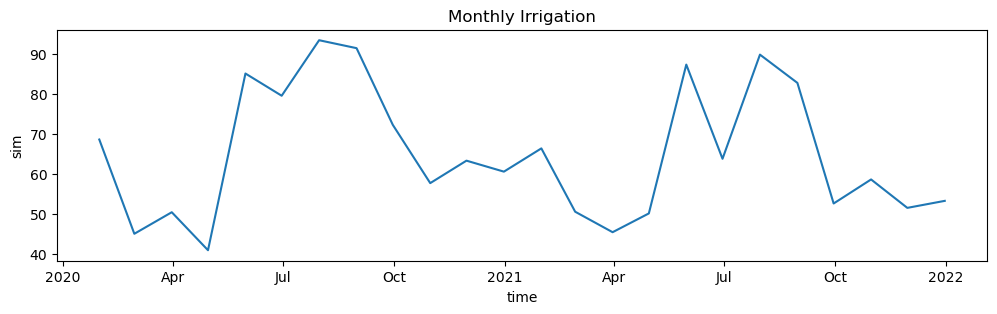

In [26]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,3))
IRR_monthly_mean.sim.plot()
plt.title("Monthly Irrigation")
plt.show()